# Custom Dataset:

Pytorch Datasets -> torchvision.datasets, torchtext.datasets, torchaudio.datasets, torchrec.datasets

TorchData -> contains helper functions for loading data

We work with the subclass of food 101 custom dataset that contains pictures of 101 different foods, here we have only 3 of them in the zip file

Food101 -> 101 classes and 1000 images for each class

Our dataset -> 3 classes and 100 images for each class(75 training and 25 testing)

## Loading images from standard folder

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
device="cuda" if torch.cuda.is_available() else "cpu"
!nvidia-smi
device

Thu Jun 11 18:38:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.04              Driver Version: 596.21         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:F3:00.0 Off |                  N/A |
| N/A   39C    P8              3W /   33W |     982MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

'cuda'

In [2]:
import zipfile
from pathlib import Path

In [3]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

In [4]:
if image_path.is_dir():
    print("image path already exists!")
else:
    image_path.mkdir(parents=True, exist_ok=True)

image path already exists!


In [5]:
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    zip_ref.extractall(image_path)

In [6]:
import os
trainpath = Path(image_path / "train")
testpath = Path(image_path / "test")

for dirpath, dirname, filename in os.walk(trainpath): # walks over different path and see folder names(dirname) and also file names.
    print(dirpath, dirname ,filename,"\n")

for dirpath, dirname, filename in os.walk(testpath):
    print(dirpath, dirname ,filename,"\n")

data/pizza_steak_sushi/train ['steak', 'sushi', 'pizza'] [] 

data/pizza_steak_sushi/train/steak [] ['231296.jpg', '1761285.jpg', '2013535.jpg', '1736968.jpg', '234626.jpg', '2129685.jpg', '443210.jpg', '167069.jpg', '2629750.jpg', '1961025.jpg', '75537.jpg', '97656.jpg', '1264154.jpg', '1966300.jpg', '482022.jpg', '214320.jpg', '2287136.jpg', '1647351.jpg', '830007.jpg', '2606444.jpg', '1937872.jpg', '1849463.jpg', '2163079.jpg', '165639.jpg', '2614189.jpg', '2222018.jpg', '3857508.jpg', '1225762.jpg', '1615395.jpg', '100135.jpg', '3245622.jpg', '1382427.jpg', '1621763.jpg', '1787505.jpg', '3518960.jpg', '2254705.jpg', '2324994.jpg', '2561199.jpg', '2628106.jpg', '1839481.jpg', '3142045.jpg', '461689.jpg', '3142674.jpg', '922752.jpg', '2881783.jpg', '1257104.jpg', '1976160.jpg', '3727491.jpg', '2878151.jpg', '3577618.jpg', '2614649.jpg', '1413972.jpg', '421476.jpg', '2979061.jpg', '339891.jpg', '560503.jpg', '2603058.jpg', '3074367.jpg', '937133.jpg', '1624747.jpg', '256592.jpg', '225

data/pizza_steak_sushi/train/sushi/2720223.jpg


(512, 512, 3)

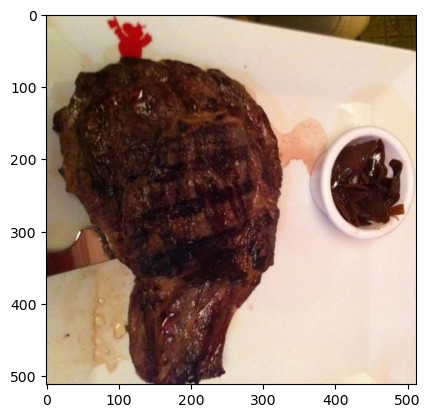

In [7]:
import random
random.seed(42)
from PIL import Image
train_paths = []
for dirpath, dirname,filenames in os.walk(trainpath):
    for name in filenames:
        train_paths.append(dirpath +"/"+name)
print(train_paths[random.randint(0,100)])
img = Image.open(train_paths[random.randint(0,100)])
plt.imshow(np.array(img))
np.array(img).shape

## Transforming Data for Tensor

1- First, we need to convert our targets to tensors

2- Second, we should convert our data into torch.utils.data.Dataset and then to torch.utils.data.DataLoader

In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset #DataLoader and Dataset
from torchvision import datasets, transforms #torchvision datasets and transform

In [9]:
image_transform = transforms.Compose([ # it combines multiple transforms
    transforms.Resize((64,64)), # we want to resize all images to have same size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor() #it converts PIL or ndarray to tensor. also the color channel will be at the first index!
])

In [10]:
image_tensor = image_transform(img)

In [11]:
image_tensor.shape

torch.Size([3, 64, 64])

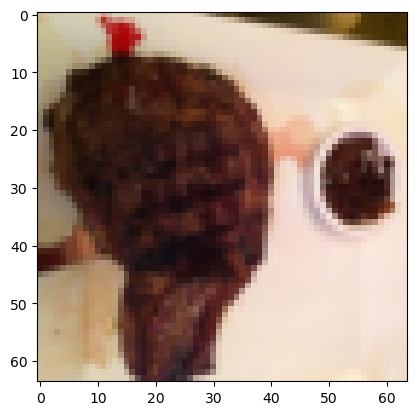

In [12]:
plt.imshow(image_tensor.permute(1,2,0).numpy())

## loading all images data from standard folders using torchvision.datasets.ImageFolder and create dataset

In [13]:
from torchvision.datasets import ImageFolder
train_data = ImageFolder(root=trainpath,
                         transform=image_transform,
                         target_transform=None) #we do not need this transform
test_data = ImageFolder(root=testpath,
                         transform=image_transform,
                         target_transform=None) #we do not need this transform

In [14]:
len(test_data), len(train_data), train_data.classes, train_data.class_to_idx

(75, 225, ['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

torch.Size([3, 64, 64]) 0


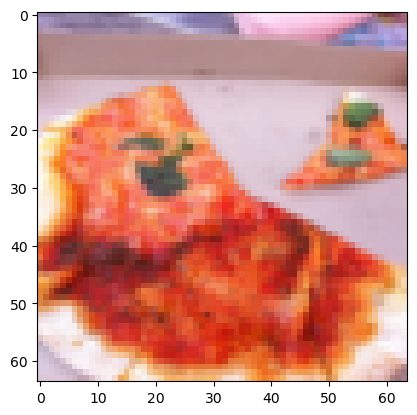

In [15]:
img = train_data[21][0]
target = train_data[21][1]
print(img.shape, target)
plt.imshow(img.permute(1,2,0))

pizza


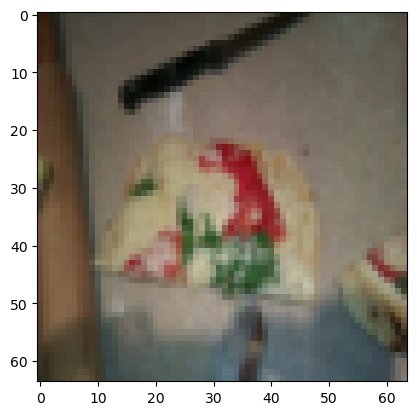

In [16]:
def display_images(dataset:torch.utils.data.Dataset,
                          classes:list[str]=None,
                          n:int=10):
    imge,label = dataset[n]
    plt.imshow(imge.permute(1,2,0))
    class_name = next((k for k, v in dataset.class_to_idx.items() if v == label), None)
    print(class_name)
display_images(train_data,train_data.classes,29)

## loading all images data from standard folders without ImageFolder
Make something that is usable by torch.utils.data.DataLoader

get images from folders, get class names from folder names, get classes as a dictionary

In [17]:
import os
from pathlib import Path
import pathlib
import torch
from torch.utils.data import Dataset
from PIL import Image
import PIL
from torchvision import transforms
from typing import Tuple, List, Dict

In [18]:
# instance of torchvision.datasets.DataFolder
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [19]:
# all custom datasets in pytorch subclass from : torch.utils.data.Dataset
train_dir = Path(image_path / "train")
test_dir = Path(image_path / "test")
    
class ImageFolderCustom(torch.utils.data.Dataset):
    def __init__(self,targ_dir: str, transform=None):
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.classes, self.class_to_idx = self.find_classes(targ_dir)
        self.transform = transform

    def load_image(self,index):
        image_path = self.paths[index]
        return PIL.Image.open(image_path)
        
    def __len__(self):
        return len(self.paths)
        
    def find_classes(self,directory):
        classes = sorted([entry.name for entry in list(os.scandir(directory)) if entry.is_dir()])
        if not classes:
            raise FileNotFoundError(f"Could not find classes in{directory}")
        class_to_idx = {class_name:i for i,class_name in enumerate(classes)}
        return classes,class_to_idx

    # mandatory to overwrite (returns image tensor and label)
    def __getitem__(self,index):
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        return img, class_idx

75 , 225


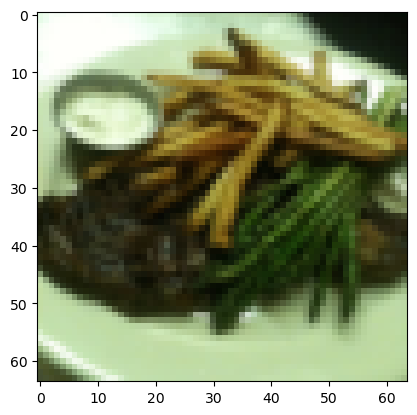

In [20]:
from torchvision import transforms
train_transforms = transforms.Compose([
                                      transforms.Resize(size=(64, 64)),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.ToTensor() 
])

test_transforms = transforms.Compose([
                                      transforms.Resize(size=(64, 64)),
                                      transforms.ToTensor()
])

test_data_custom = ImageFolderCustom(test_dir,test_transforms)
train_data_custom = ImageFolderCustom(train_dir,train_transforms)

print(len(test_data_custom),",",len(train_data_custom))
img,_ = train_data_custom.__getitem__(4)
img.shape
plt.imshow(img.permute(1,2,0).numpy())

## Create dataloader (minibatches from data) (iterable dataset for training) for custom dataset

In [21]:
from torch.utils.data import DataLoader
BATCH_SIZE =32
train_dataloader_custom = DataLoader(train_data_custom, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count())
test_dataloader_custom = DataLoader(test_data_custom, batch_size=BATCH_SIZE, shuffle=False,  num_workers=os.cpu_count())

batch,label = next(iter(train_dataloader_custom))
batch.shape, label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## Create dataloader (minibatches from data) (iterable dataset for training) for dataset from ImageFolder

In [22]:
import os
os.cpu_count()

8

In [23]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True,
                             num_workers=os.cpu_count())
test_dataloader = DataLoader(dataset=test_data,
                             batch_size= BATCH_SIZE,
                             shuffle = False,  # we do not shuffle for test data
                             num_workers=os.cpu_count()) # more -> better!

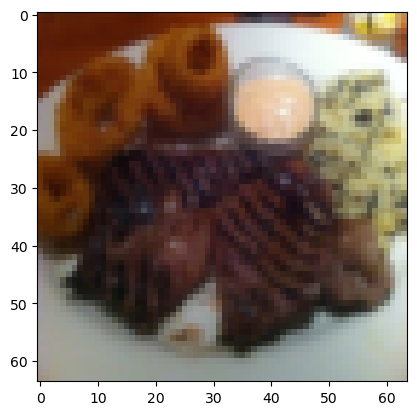

In [24]:
BatchData,BatchLabel = next(iter(train_dataloader))
plt.imshow(BatchData[31].permute(1,2,0))

In [25]:
for batch_data,targets in train_dataloader:
    print(batch_data.shape,"\n", targets)

torch.Size([32, 3, 64, 64]) 
 tensor([2, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 1, 2, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 2,
        0, 0, 1, 0, 1, 0, 0, 0])
torch.Size([32, 3, 64, 64]) 
 tensor([1, 2, 1, 1, 2, 0, 1, 2, 2, 0, 2, 2, 1, 1, 2, 0, 1, 1, 0, 2, 0, 1, 1, 0,
        0, 1, 1, 1, 2, 0, 2, 1])
torch.Size([32, 3, 64, 64]) 
 tensor([1, 1, 0, 0, 1, 0, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 0, 2, 1, 2, 1, 0, 2, 0,
        0, 2, 1, 1, 0, 0, 2, 1])
torch.Size([32, 3, 64, 64]) 
 tensor([1, 1, 1, 2, 1, 0, 2, 0, 0, 0, 1, 2, 0, 1, 1, 1, 2, 1, 2, 1, 0, 0, 2, 1,
        0, 2, 1, 1, 0, 0, 0, 0])
torch.Size([32, 3, 64, 64]) 
 tensor([0, 1, 1, 2, 2, 1, 2, 0, 0, 2, 2, 2, 2, 0, 2, 2, 0, 2, 0, 0, 0, 0, 2, 2,
        0, 1, 2, 0, 0, 0, 1, 2])
torch.Size([32, 3, 64, 64]) 
 tensor([1, 0, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 1, 0, 0, 0, 2, 1, 1, 2, 0, 2, 0, 1,
        0, 1, 1, 0, 1, 2, 0, 2])
torch.Size([32, 3, 64, 64]) 
 tensor([2, 2, 2, 2, 1, 1, 2, 1, 0, 1, 1, 0, 1, 1, 1, 0, 2, 1, 2, 0, 2, 2, 2, 2,
        2, 2, 1, 0, 0, 1, 0, 0])

# Data Augmentation using torchvision.transforms
resize, crop, randomtransform, grayscale, gaussian blur, random perspective (see from different view), random rotation

In [26]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize(size =(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=5), #this can be 31 max and that is the maximum transformation
    transforms.ToTensor
])

#test transform without data augmentation
test_transform = transforms.Compose([ 
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [27]:
image_path_list = list(image_path.glob("*/*/*.jpg"))

In [28]:
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/steak/1285886.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2117351.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2144308.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/673127.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1868005.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/354513.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/3873283.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1302563.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1016217.jpg')]

# Tiny VGG with augmentation

In [32]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
import os
from pathlib import Path
from tqdm.auto import tqdm

image_path = Path("data/pizza_steak_sushi")
BATCH_SIZE = 32
train_transform = transforms.Compose([
        transforms.Resize(size=(64,64)),
        transforms.TrivialAugmentWide(31),
        transforms.ToTensor()
])
test_transform = transforms.Compose([
        transforms.Resize(size=(64,64)),
        transforms.ToTensor()
])

train_data = torchvision.datasets.ImageFolder(root = image_path / "train",
                                              transform=train_transform)
test_data = torchvision.datasets.ImageFolder(root = image_path / "test",
                                              transform=test_transform)

train_dataloader = torch.utils.data.DataLoader(train_data,
                                               batch_size=BATCH_SIZE,
                                               num_workers=os.cpu_count(),
                                               shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_data,
                                              batch_size=BATCH_SIZE,
                                              num_workers=os.cpu_count(),
                                              shuffle=False)

In [33]:
class VGG_model(nn.Module):
    def __init__(self,input_shape,hidden_units,output_shape):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(in_channels=input_shape,
                                            out_channels=hidden_units,
                                            kernel_size=3,
                                            stride=1,
                                            padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=hidden_units,
                                           out_channels=hidden_units,
                                           kernel_size=3,
                                           stride=1,
                                           padding=1),
                                  nn.ReLU(),
                                  nn.MaxPool2d(kernel_size=2,
                                              stride=2)
                                  )
        self.conv2 = nn.Sequential(nn.Conv2d(in_channels=hidden_units,
                                            out_channels=hidden_units,
                                            kernel_size=3,
                                            stride=1,
                                            padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=hidden_units,
                                           out_channels=hidden_units,
                                           kernel_size=3,
                                           stride=1,
                                           padding=1),
                                  nn.ReLU(),
                                  nn.MaxPool2d(kernel_size=2,
                                              stride=2)
                                  )
        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(in_features=hidden_units*16*16, # derived by printing a forward pass
                                                  out_features=output_shape))
    def forward(self,x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.classifier(x)
        return x
        #return self.classifier(self.conv2(self.conv1(x))) faster approach because of operator fusion

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
MyModel = VGG_model(3, #number of color chanels
                    64,
                    output_shape = len(train_data.classes)).to(device)


In [35]:
MyModel.train() 
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 20
optimizer = torch.optim.Adam(MyModel.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in tqdm(range(epochs)):
    train_loss, train_acc=0, 0 
    test_loss, test_acc = 0, 0
    for batch, (X,y) in enumerate(train_dataloader):
        X,y = X.to(device), y.to(device)
        y_pred = MyModel(X)
        loss =loss_fn(y_pred,y)
        train_loss +=loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1),dim=1)
        train_acc +=(y_pred_class==y).sum().item()/len(y_pred)
    train_loss = train_loss/len(train_dataloader)
    train_acc = train_acc/len(train_dataloader)
    
    MyModel.eval()
    with torch.inference_mode():
        for batch, (X_test,y_test) in enumerate(test_dataloader):
            X_test,y_test = X_test.to(device),y_test.to(device)
            y_pred_test = MyModel(X_test)
            loss = loss_fn(y_pred_test, y_test)
            test_loss +=loss.item()
            y_pred_test_class = torch.argmax(torch.softmax(y_pred_test,dim=1),dim=1)
            test_acc += (y_pred_test_class==y_test).sum().item()/len(y_pred_test_class)
        test_loss = test_loss /len(test_dataloader)
        test_acc = test_acc /len(test_dataloader)
    print(f"epoch ={epoch}, train_loss = {train_loss:.4f}, train_acc = {train_acc:.4f}, test_loss = {test_loss:.4f}, test_acc = {test_acc:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

epoch =0, train_loss = 0.9466, train_acc = 0.5820, test_loss = 1.2697, test_acc = 0.3324
epoch =1, train_loss = 0.9532, train_acc = 0.5781, test_loss = 1.0240, test_acc = 0.4148
epoch =2, train_loss = 0.8701, train_acc = 0.6367, test_loss = 1.0278, test_acc = 0.4044
epoch =3, train_loss = 0.7876, train_acc = 0.6133, test_loss = 1.0410, test_acc = 0.4138
epoch =4, train_loss = 0.7722, train_acc = 0.6289, test_loss = 0.9985, test_acc = 0.4744
epoch =5, train_loss = 0.9750, train_acc = 0.4805, test_loss = 1.0095, test_acc = 0.4337
epoch =6, train_loss = 0.8304, train_acc = 0.6289, test_loss = 1.0143, test_acc = 0.4242
epoch =7, train_loss = 0.8664, train_acc = 0.6797, test_loss = 1.1526, test_acc = 0.3532
epoch =8, train_loss = 0.8857, train_acc = 0.5898, test_loss = 1.0514, test_acc = 0.4953
epoch =9, train_loss = 0.8820, train_acc = 0.6211, test_loss = 1.0593, test_acc = 0.4138
epoch =10, train_loss = 0.8270, train_acc = 0.5938, test_loss = 1.0832, test_acc = 0.4034
epoch =11, train_los

# Ways of Improvement
### Early Stopping -> stop training right befor overfitting -> before test loss start to increase in loss curve plot
### Learning Rate Decay -> help not getting stuck around local optimum
### Transfer Learning -> use pretrained models

True Label = steak
Predicted label = steak


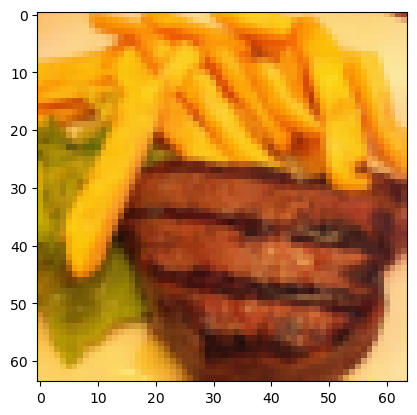

In [65]:
img,label = test_data[40]
type(img)
plt.imshow(img.permute(1,2,0).numpy())
idx_to_class = {v: k for k, v in train_data.class_to_idx.items()}
print(f"True Label = {idx_to_class[label]}\nPredicted label = {idx_to_class[torch.argmax(MyModel(img.unsqueeze(0).to(device))).cpu().item()]}") #our model needs batch dimension